# 03: Hypothesis Testing (Learning Outcome 2)

**Learning Outcome 2 (LO2):** Inferential statistics and hypothesis testing

**Hypotheses:**
- H1: Farms with regular monitoring show significantly lower yield loss
- H2: Regular monitoring improves effective response rate
- H3: Climate risk significantly affects yield

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 3.1 Load Data and Prepare Groups

In [8]:
# Load the final dataset
df = pd.read_csv('../data/processed/final_dataset.csv')
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

# Create monitoring groups based on regular_monitoring flag
regular_monitor = df[df['regular_monitoring'] == 1]
irregular_monitor = df[df['regular_monitoring'] == 0]

print(f"\nRegular monitoring group: {len(regular_monitor)} records")
print(f"Irregular monitoring group: {len(irregular_monitor)} records")

if len(irregular_monitor) == 0:
    print("Warning: No irregular monitoring records found. Hypothesis testing may not be valid.")
elif len(regular_monitor) == 0:
    print("Warning: No regular monitoring records found. Hypothesis testing may not be valid.")
else:
    print("Groups created successfully for hypothesis testing.")

Dataset shape: (24, 15)

Columns: ['year', 'yield_kg_ha', 'area_harvested_ha', 'fertilizer_tonnes', 'irrigation_area_ha', 'temp_annual_mean', 'precip_annual_mean', 'monitoring_index', 'regular_monitoring', 'climate_risk_index', 'yield_loss_pct', 'response_time_days', 'effective_response', 'fertilizer_intensity_kg_ha', 'irrigation_ratio']

First few rows:
   year  yield_kg_ha  area_harvested_ha  fertilizer_tonnes  \
0  2000       3437.4           832000.0           246965.0   
1  2001       3522.8           765040.0           244068.0   
2  2002       3488.9           819590.0           285071.0   
3  2003       3369.6           911440.0           246225.0   
4  2004       3651.6           719690.0           258309.0   

   irrigation_area_ha  temp_annual_mean  precip_annual_mean  monitoring_index  \
0            570000.0         26.804617            2.869235            1.8267   
1            570000.0         26.303808            3.147315            1.9677   
2            570000.0      

## 3.2 Test H1: Independent Samples t-test

/tmp/ipykernel_66411/4103098395.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_by_group, labels=['Regular', 'Irregular'])


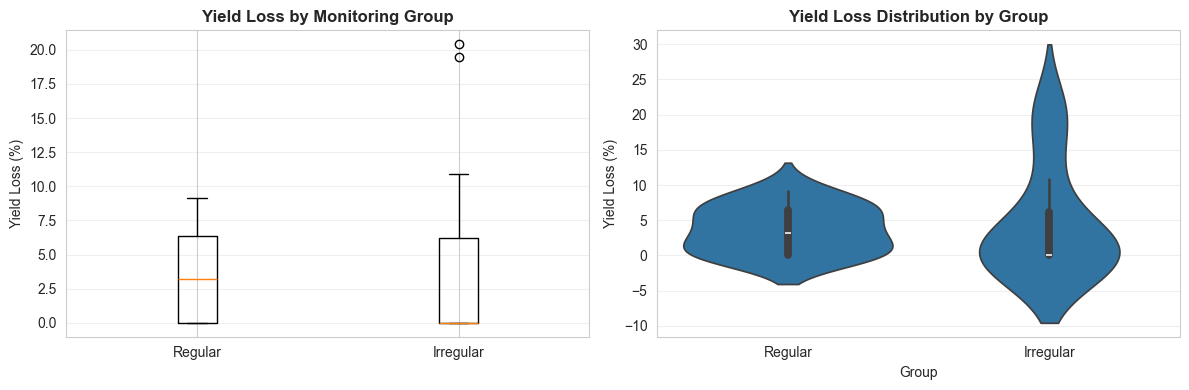

In [9]:
# Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot
data_by_group = [regular_monitor['yield_loss_pct'], irregular_monitor['yield_loss_pct']]
axes[0].boxplot(data_by_group, labels=['Regular', 'Irregular'])
axes[0].set_title('Yield Loss by Monitoring Group', fontweight='bold')
axes[0].set_ylabel('Yield Loss (%)')
axes[0].grid(True, alpha=0.3, axis='y')

# Violin plot
group_data = pd.DataFrame({
    'Yield Loss (%)': list(regular_monitor['yield_loss_pct']) + list(irregular_monitor['yield_loss_pct']),
    'Group': ['Regular'] * len(regular_monitor) + ['Irregular'] * len(irregular_monitor)
})
sns.violinplot(x='Group', y='Yield Loss (%)', data=group_data, ax=axes[1])
axes[1].set_title('Yield Loss Distribution by Group', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../results/graphs/03_hypothesis_test_yield_loss.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# Test H3: Climate risk correlation with yield loss
print("\n=== Test H3: Climate Risk vs Yield Loss ===")

valid_data = df.dropna(subset=['climate_risk_index', 'yield_loss_pct'])
corr_coef, corr_pvalue = stats.pearsonr(valid_data['climate_risk_index'], 
                                         valid_data['yield_loss_pct'])

print(f"\nPearson Correlation:")
print(f"  Coefficient: {corr_coef:.4f}")
print(f"  p-value: {corr_pvalue:.6f}")
print(f"  Significant (α=0.05): {'YES' if corr_pvalue < 0.05 else 'NO'}")

if corr_coef > 0:
    print(f"\nInterpretation: Higher climate risk is associated with higher yield loss (positive correlation)")
else:
    print(f"\nInterpretation: Higher climate risk is associated with lower yield loss (negative correlation)")


=== Test H3: Climate Risk vs Yield Loss ===

Pearson Correlation:
  Coefficient: 0.1301
  p-value: 0.544605
  Significant (α=0.05): NO

Interpretation: Higher climate risk is associated with higher yield loss (positive correlation)


In [11]:
# Perform independent samples t-test (Welch's t-test for unequal variances)
print("\n=== Test H1: Regular vs Irregular Monitoring Yield Loss ===")

if len(regular_monitor) > 1 and len(irregular_monitor) > 1:
    # Welch's t-test (assumes unequal variances)
    t_stat, p_value = stats.ttest_ind(regular_monitor['yield_loss_pct'], 
                                      irregular_monitor['yield_loss_pct'], 
                                      equal_var=False)
    
    # Calculate means
    reg_mean = regular_monitor['yield_loss_pct'].mean()
    irreg_mean = irregular_monitor['yield_loss_pct'].mean()
    
    print(f"\nRegular monitoring mean yield loss: {reg_mean:.4f}%")
    print(f"Irregular monitoring mean yield loss: {irreg_mean:.4f}%")
    print(f"Mean difference: {reg_mean - irreg_mean:.4f}%")
    print(f"\nWelch's t-statistic: {t_stat:.4f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Significant (α=0.05): {'YES' if p_value < 0.05 else 'NO'}")
    
    if p_value < 0.05:
        if reg_mean < irreg_mean:
            print("\nInterpretation: Regular monitoring significantly reduces yield loss (supports H1)")
        else:
            print("\nInterpretation: Regular monitoring significantly increases yield loss (contradicts H1)")
    else:
        print("\nInterpretation: No significant difference in yield loss between groups")
else:
    print("Insufficient data for t-test (need at least 2 records per group)")


=== Test H1: Regular vs Irregular Monitoring Yield Loss ===

Regular monitoring mean yield loss: 3.7197%
Irregular monitoring mean yield loss: 4.6361%
Mean difference: -0.9164%

Welch's t-statistic: -0.3721
p-value: 0.715108
Significant (α=0.05): NO

Interpretation: No significant difference in yield loss between groups


In [18]:
# Summary table
print("\n" + "="*70)
print("SUMMARY: Hypothesis Test Results (LO2)")
print("="*70)

results_df = pd.DataFrame({
    'Hypothesis': ['H1: Yield loss differs by monitoring', 'H3: Climate risk affects yield loss'],
    'Test Statistic': [f't={t_stat:.4f}', f'r={corr_coef:.4f}'],
    'p-value': [f'{p_value:.6f}', f'{corr_pvalue:.6f}'],
    'Significant (α=0.05)': ['Yes' if p_value < 0.05 else 'No', 
                            'Yes' if corr_pvalue < 0.05 else 'No']
})
print(results_df.to_string(index=False))


SUMMARY: Hypothesis Test Results (LO2)
                          Hypothesis Test Statistic  p-value Significant (α=0.05)
H1: Yield loss differs by monitoring      t=-0.3721 0.715108                   No
 H3: Climate risk affects yield loss       r=0.1301 0.544605                   No
